In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
df = pd.read_csv("realistic_kraljic_dataset.csv")

In [76]:
df

,Product_ID,Product_Name,Supplier_Region,Lead_Time_Days,Order_Volume_Units,Cost_per_Unit,Supply_Risk_Score,Profit_Impact_Score,Environmental_Impact,Single_Source_Risk,Kraljic_Category
0,P001,Semiconductors,South America,81,171,255.03,5,5,4,Yes,Strategic
1,P002,Semiconductors,South America,8,763,380.33,5,4,4,Yes,Strategic
2,P003,Pharma APIs,Asia,65,413,385.24,4,5,5,Yes,Strategic
3,P004,Semiconductors,South America,70,882,287.64,5,5,5,Yes,Strategic
4,P005,Lithium Batteries,Asia,15,120,382.26,4,4,4,Yes,Strategic
...,...,...,...,...,...,...,...,...,...,...,...
995,P996,Printer Ink,Global,19,19648,10.20,2,1,1,No,Non-Critical
996,P997,Cleaning Supplies,Global,21,19143,15.30,1,2,1,No,Non-Critical
997,P998,Uniforms,Global,70,5352,30.23,1,3,2,No,Non-Critical
998,P999,Printer Ink,Global,44,18070,30.73,1,1,2,No,Non-Critical


In [77]:
df.shape
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   object 
 1   Product_Name          1000 non-null   object 
 2   Supplier_Region       1000 non-null   object 
 3   Lead_Time_Days        1000 non-null   int64  
 4   Order_Volume_Units    1000 non-null   int64  
 5   Cost_per_Unit         1000 non-null   float64
 6   Supply_Risk_Score     1000 non-null   int64  
 7   Profit_Impact_Score   1000 non-null   int64  
 8   Environmental_Impact  1000 non-null   int64  
 9   Single_Source_Risk    1000 non-null   object 
 10  Kraljic_Category      1000 non-null   object 
dtypes: float64(1), int64(5), object(5)
memory usage: 86.1+ KB


Product_ID              0
Product_Name            0
Supplier_Region         0
Lead_Time_Days          0
Order_Volume_Units      0
Cost_per_Unit           0
Supply_Risk_Score       0
Profit_Impact_Score     0
Environmental_Impact    0
Single_Source_Risk      0
Kraljic_Category        0
dtype: int64

In [78]:
df['Kraljic_Category'].value_counts()

Kraljic_Category
Strategic       250
Bottleneck      250
Leverage        250
Non-Critical    250
Name: count, dtype: int64

In [79]:
df.describe()

,Lead_Time_Days,Order_Volume_Units,Cost_per_Unit,Supply_Risk_Score,Profit_Impact_Score,Environmental_Impact
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,47.508000,4753.182000,169.390440,2.988000,3.024000,2.778000
std,23.630454,5625.105273,132.104809,1.537602,1.542661,1.392356
min,7.000000,50.000000,10.090000,1.000000,1.000000,1.000000
25%,27.000000,363.000000,50.460000,1.000000,2.000000,2.000000
50%,48.000000,1105.500000,130.640000,3.000000,3.000000,2.500000
75%,67.000000,8111.750000,255.165000,4.250000,5.000000,4.000000
max,89.000000,19940.000000,499.320000,5.000000,5.000000,5.000000


In [80]:
df = df.drop(['Product_ID','Product_Name'], axis=1)

In [81]:
df

,Supplier_Region,Lead_Time_Days,Order_Volume_Units,Cost_per_Unit,Supply_Risk_Score,Profit_Impact_Score,Environmental_Impact,Single_Source_Risk,Kraljic_Category
0,South America,81,171,255.03,5,5,4,Yes,Strategic
1,South America,8,763,380.33,5,4,4,Yes,Strategic
2,Asia,65,413,385.24,4,5,5,Yes,Strategic
3,South America,70,882,287.64,5,5,5,Yes,Strategic
4,Asia,15,120,382.26,4,4,4,Yes,Strategic
...,...,...,...,...,...,...,...,...,...
995,Global,19,19648,10.20,2,1,1,No,Non-Critical
996,Global,21,19143,15.30,1,2,1,No,Non-Critical
997,Global,70,5352,30.23,1,3,2,No,Non-Critical
998,Global,44,18070,30.73,1,1,2,No,Non-Critical


In [82]:
df['Single_Source_Risk'] = df['Single_Source_Risk'].map({
    'Yes':1,
    'No':0
})

In [83]:
df

,Supplier_Region,Lead_Time_Days,Order_Volume_Units,Cost_per_Unit,Supply_Risk_Score,Profit_Impact_Score,Environmental_Impact,Single_Source_Risk,Kraljic_Category
0,South America,81,171,255.03,5,5,4,1,Strategic
1,South America,8,763,380.33,5,4,4,1,Strategic
2,Asia,65,413,385.24,4,5,5,1,Strategic
3,South America,70,882,287.64,5,5,5,1,Strategic
4,Asia,15,120,382.26,4,4,4,1,Strategic
...,...,...,...,...,...,...,...,...,...
995,Global,19,19648,10.20,2,1,1,0,Non-Critical
996,Global,21,19143,15.30,1,2,1,0,Non-Critical
997,Global,70,5352,30.23,1,3,2,0,Non-Critical
998,Global,44,18070,30.73,1,1,2,0,Non-Critical


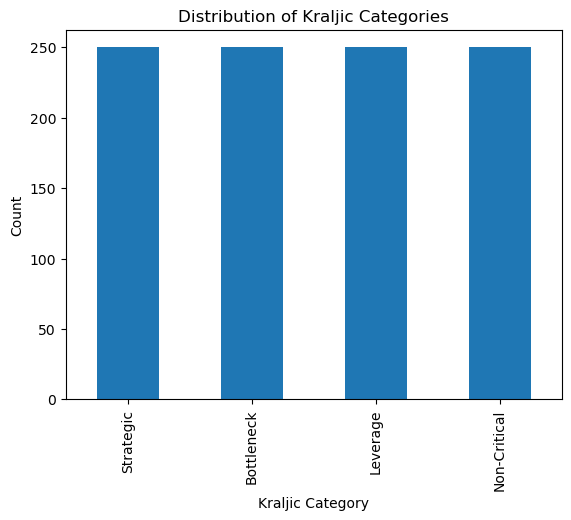

In [84]:
import matplotlib.pyplot as plt

df["Kraljic_Category"].value_counts().plot(kind="bar")
plt.title("Distribution of Kraljic Categories")
plt.xlabel("Kraljic Category")
plt.ylabel("Count")
plt.show()

This graph shows that all four Kraljic categories are perfectly balanced with 250 records each.

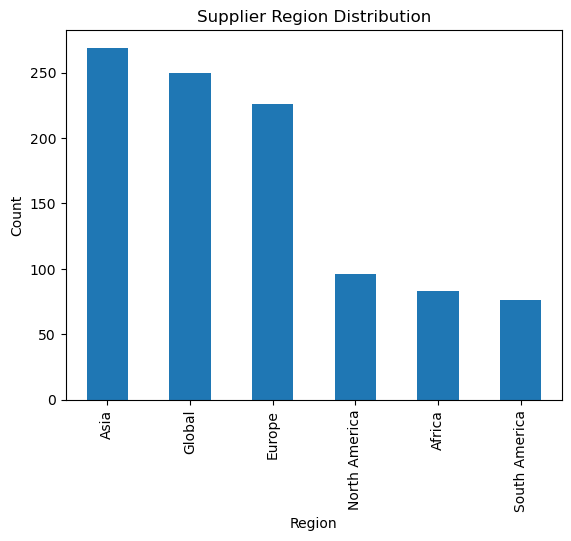

In [85]:
df["Supplier_Region"].value_counts().plot(kind="bar")
plt.title("Supplier Region Distribution")
plt.xlabel("Region")
plt.ylabel("Count")
plt.show()

This graph shows that Asia is the most common supplier region, followed by Global and Europe, while South America and Africa are least represented.

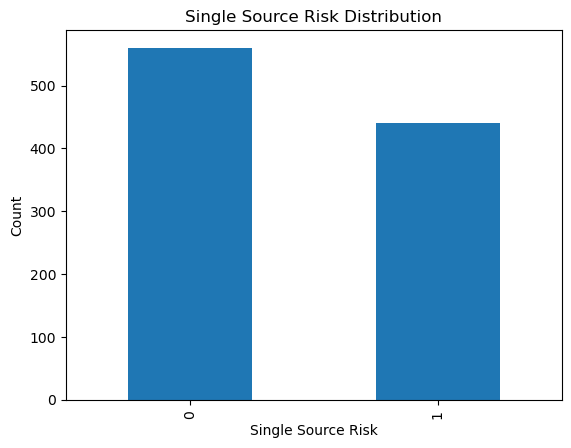

In [86]:
df["Single_Source_Risk"].value_counts().plot(kind="bar")
plt.title("Single Source Risk Distribution")
plt.xlabel("Single Source Risk")
plt.ylabel("Count")
plt.show()

This graph shows that most products are not single-sourced (560 No vs 440 Yes).

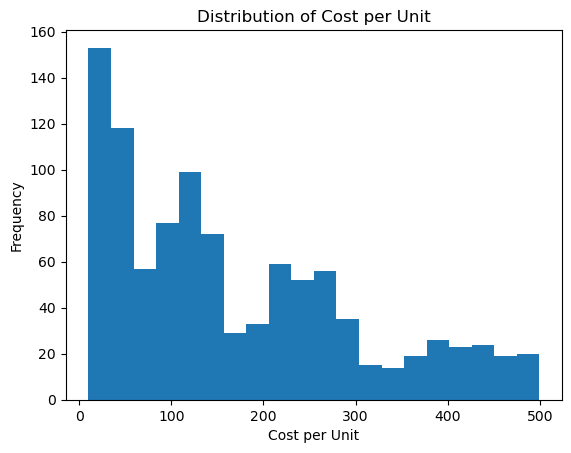

In [87]:
plt.hist(df["Cost_per_Unit"], bins=20)
plt.title("Distribution of Cost per Unit")
plt.xlabel("Cost per Unit")
plt.ylabel("Frequency")
plt.show()

This graph shows that most products have low to medium cost and only a smaller portion have very high cost values.

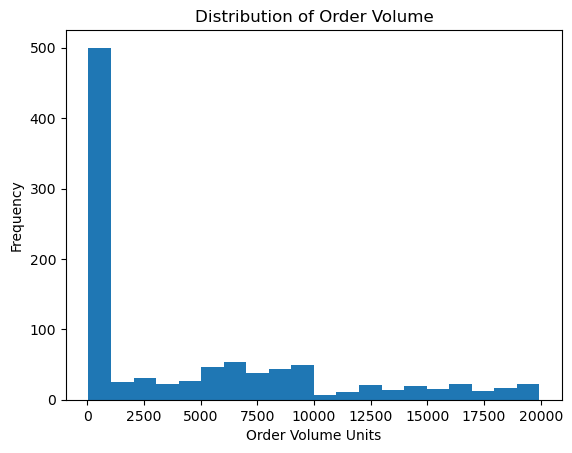

In [88]:
plt.hist(df["Order_Volume_Units"], bins=20)
plt.title("Distribution of Order Volume")
plt.xlabel("Order Volume Units")
plt.ylabel("Frequency")
plt.show()

This graph shows that the dataset contains many low-volume orders and fewer very large order volumes.

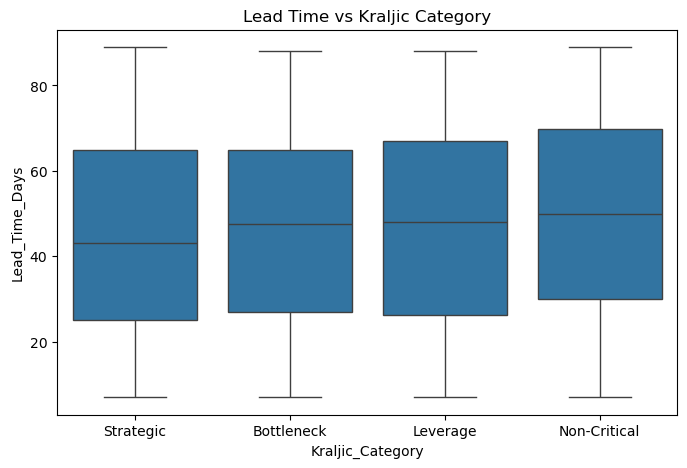

In [89]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(
    x="Kraljic_Category",
    y="Lead_Time_Days",
    data=df
)
plt.title("Lead Time vs Kraljic Category")
plt.show()

This graph shows that lead time is almost similar for all Kraljic categories and does not strongly separate the classes.

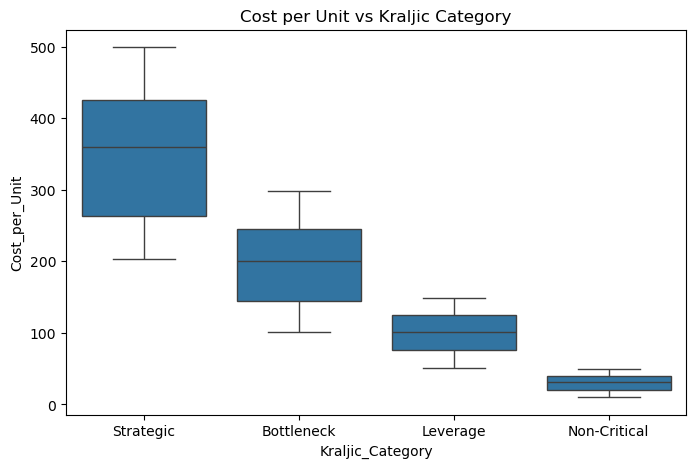

In [90]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x="Kraljic_Category",
    y="Cost_per_Unit",
    data=df
)
plt.title("Cost per Unit vs Kraljic Category")
plt.show()

This graph shows that Strategic items have the highest cost per unit, while Non-Critical items have the lowest cost.

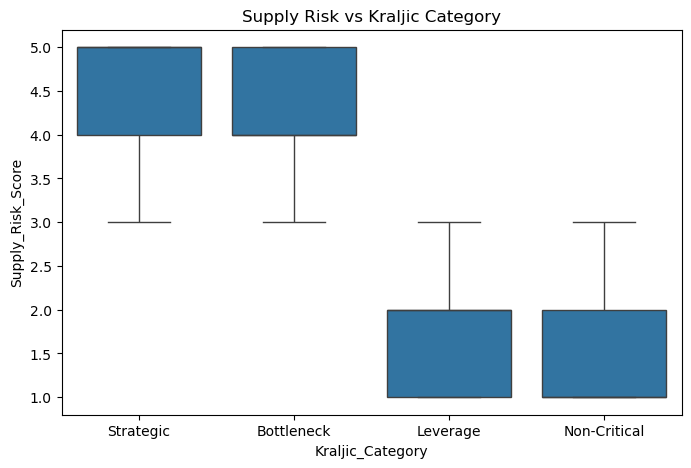

In [91]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x="Kraljic_Category",
    y="Supply_Risk_Score",
    data=df
)
plt.title("Supply Risk vs Kraljic Category")
plt.show()

This graph shows that Strategic and Bottleneck items have much higher supply risk than Leverage and Non-Critical items.

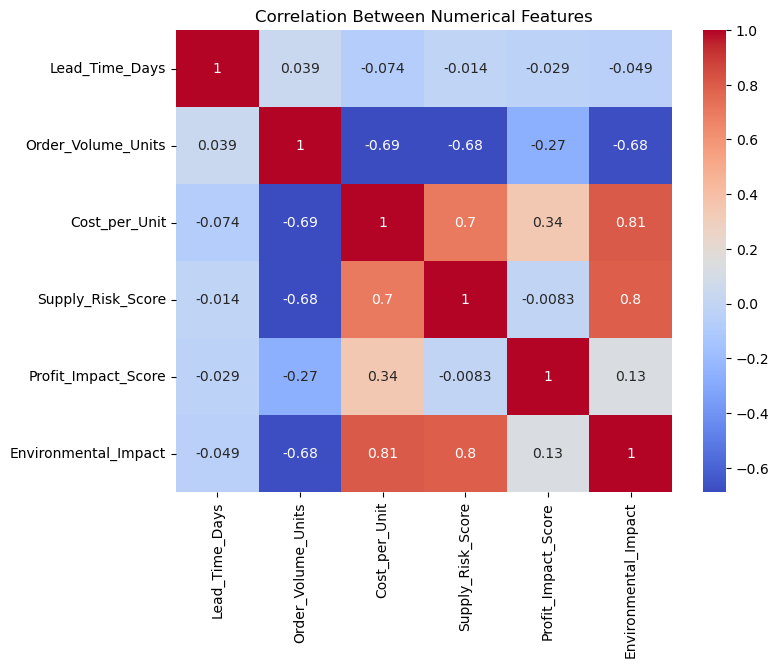

In [92]:
num_cols = [
    "Lead_Time_Days",
    "Order_Volume_Units",
    "Cost_per_Unit",
    "Supply_Risk_Score",
    "Profit_Impact_Score",
    "Environmental_Impact"
]

plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Numerical Features")
plt.show()

This graph shows a strong positive relationship between cost per unit, supply risk and environmental impact, and a strong negative relationship between order volume and these variables.

In [93]:
df = pd.get_dummies(df, columns=["Supplier_Region"], drop_first=True)

In [94]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Kraljic_Category"] = le.fit_transform(df["Kraljic_Category"])

le.classes_

array(['Bottleneck', 'Leverage', 'Non-Critical', 'Strategic'],
      dtype=object)

In [95]:
X = df.drop("Kraljic_Category", axis=1)
y = df["Kraljic_Category"]

In [97]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [98]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [99]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [100]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results.append((name, acc))

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df.sort_values(by="Accuracy", ascending=False)

C:\Users\Sai\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy
0,Logistic Regression,1.00
5,Gradient Boosting,1.00
4,Random Forest,1.00
3,Decision Tree,0.99
1,KNN,0.86
2,SVM,0.79


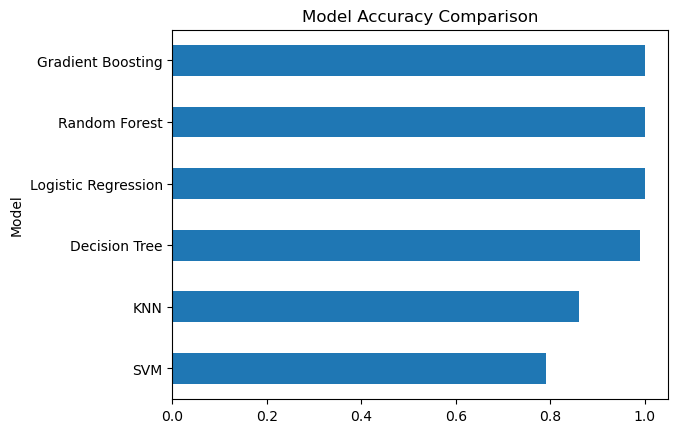

In [101]:
results_df.sort_values(by="Accuracy").plot(
    x="Model",
    y="Accuracy",
    kind="barh",
    legend=False,
    title="Model Accuracy Comparison"
)
plt.show()

In [102]:
final_model = DecisionTreeClassifier(random_state=42)
final_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [103]:
import joblib

joblib.dump(final_model, "kraljic_model.joblib")
joblib.dump(X.columns.tolist(), "kraljic_features.joblib")
joblib.dump(le, "kraljic_label_encoder.joblib")

['kraljic_label_encoder.joblib']